# 18 · PSC I형 거더 설계 — KDS 24 한계상태설계법

지간 30 m 단순 지지 PSC 거더교의 주형을 설계한다. 예제 17 에서 설계한
바닥판이 이 거더 위에 얹히므로, **합성 전후로 저항 단면이 달라지는 것**이
핵심이다.

```
① 거더 단면과 합성 단면     KDS 24 14 21 4.6
② 하중과 저항 단면          KDS 24 12 21 4.3, KDS 24 12 11 표 4.1-1
③ 도입응력 한계             KDS 24 14 21 1.5.7.2, 1.5.7.3
④ 프리스트레스 손실         KDS 24 14 21 1.5.7.4, 1.5.7.5, 3.3.2(7)
⑤ 사용한계상태 응력         KDS 24 14 21 4.2.2
⑥ 극한한계상태 휨           KDS 24 14 21 4.1.1
⑦ 텐던 배치와 핵거리        KDS 24 14 21 1.5.7.3
⑧ 강연선 수량 결정
⑨ KDS 14 대조
```

:::{warning}
여기 쓰는 단면은 **예시이며 어떤 표준도도 아니다.** 실제 설계에는 해당
표준도나 제작사 제원을 써야 한다.
:::

원리를 그림으로 따라가려면
[강의 L6 (휨)](../lectures/L6_PSC거더_휨설계.ipynb) 와
[강의 L7 (전단)](../lectures/L7_PSC거더_전단설계.ipynb) 를, 값을 슬라이더로 바꿔
보려면 [대화형 탐색기](../_static/explorer.html)의 L5 탭을 연다.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

# 한글 글꼴이 없는 환경에서도 그림이 깨지지 않도록 축 라벨은 ASCII 로 둔다
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 96

**아래 코드가 하는 일** — 이 예제가 따라갈 설계 흐름을 순서도로
그린다. 각 단계 옆에 근거 조문을 적었다.

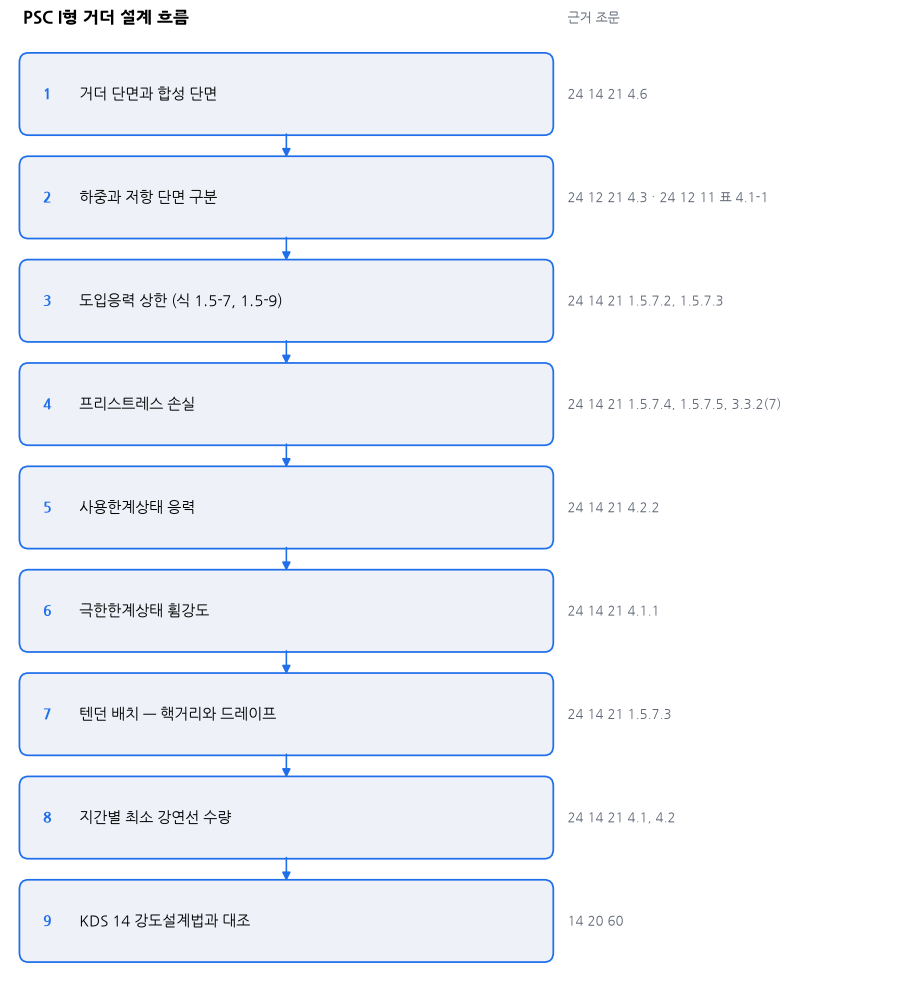

In [2]:
def _use_korean_font():
    """설치된 한글 글꼴을 찾아 matplotlib 에 등록한다.

    예제 노트북의 준비 셀은 축 라벨을 ASCII 로 두므로 글꼴을 등록하지 않는다.
    순서도는 한글을 쓰므로 여기서 직접 챙긴다.
    """
    import glob
    import sys
    from pathlib import Path

    from matplotlib import font_manager

    site = Path(sys.prefix, "lib",
                f"python{sys.version_info.major}.{sys.version_info.minor}",
                "site-packages")
    for pattern in (
        str(site / "koreanize_matplotlib/fonts/*.ttf"),
        "/usr/share/fonts/**/*Nanum*.ttf",
        "/usr/share/fonts/**/*NotoSansCJK*.ot[fc]",
        "/usr/share/fonts/**/*NotoSansKR*.otf",
    ):
        for path in glob.glob(pattern, recursive=True):
            font_manager.fontManager.addfont(path)

    installed = {f.name for f in font_manager.fontManager.ttflist}
    for name in ("NanumGothic", "Noto Sans CJK KR", "Noto Sans KR", "Malgun Gothic"):
        if name in installed:
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False


def design_flowchart(title, steps, width=9.6, box_h=0.78, gap=0.30):
    """설계 흐름을 세로 순서도로 그린다.

    Args:
        title: 그림 제목
        steps: (단계 이름, KDS 조문) 튜플의 목록. 조문에 여러 개를 적으려면
            줄바꿈 대신 쉼표로 잇는다.
        width: 그림 폭 (in)
        box_h: 상자 하나의 높이 (in 환산 전 좌표 단위)
        gap: 상자 사이 간격
    """
    from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

    _use_korean_font()

    n = len(steps)
    fig_h = n * (box_h + gap) + 0.7
    fig, ax = plt.subplots(figsize=(width, fig_h))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, n * (box_h + gap) + 0.4)
    ax.axis("off")

    face, edge = "#eef2f8", "#1f6feb"
    for i, (name, clause) in enumerate(steps):
        y = (n - 1 - i) * (box_h + gap) + 0.2
        ax.add_patch(FancyBboxPatch(
            (0.15, y), 5.9, box_h, boxstyle="round,pad=0.04,rounding_size=0.10",
            facecolor=face, edgecolor=edge, linewidth=1.3))
        ax.text(0.42, y + box_h / 2, f"{i + 1}", va="center", ha="center",
                fontsize=10.5, color=edge, fontweight="bold")
        ax.text(0.78, y + box_h / 2, name, va="center", ha="left", fontsize=11)
        ax.text(6.25, y + box_h / 2, clause, va="center", ha="left",
                fontsize=9.5, color="#5d6675")

        if i < n - 1:
            ax.add_patch(FancyArrowPatch(
                (3.1, y), (3.1, y - gap),
                arrowstyle="-|>", mutation_scale=13,
                color=edge, linewidth=1.2))

    ax.text(0.15, n * (box_h + gap) + 0.22, title, fontsize=12.5,
            fontweight="bold", va="bottom")
    ax.text(6.25, n * (box_h + gap) + 0.24, "근거 조문", fontsize=10,
            color="#5d6675", va="bottom")
    fig.tight_layout()
    return fig

design_flowchart(
"PSC I형 거더 설계 흐름",
[
    ("거더 단면과 합성 단면", "24 14 21 4.6"),
    ("하중과 저항 단면 구분", "24 12 21 4.3 · 24 12 11 표 4.1-1"),
    ("도입응력 상한 (식 1.5-7, 1.5-9)", "24 14 21 1.5.7.2, 1.5.7.3"),
    ("프리스트레스 손실", "24 14 21 1.5.7.4, 1.5.7.5, 3.3.2(7)"),
    ("사용한계상태 응력", "24 14 21 4.2.2"),
    ("극한한계상태 휨강도", "24 14 21 4.1.1"),
    ("텐던 배치 — 핵거리와 드레이프", "24 14 21 1.5.7.3"),
    ("지간별 최소 강연선 수량", "24 14 21 4.1, 4.2"),
    ("KDS 14 강도설계법과 대조", "14 20 60"),
],
)
plt.show()

In [3]:
from concreteproperties_kds.kds import stress_block_parameters
from concreteproperties_kds.kds24 import (
    COMBINATIONS_BY_NAME, EXAMPLE_SECTIONS, GAMMA_CONCRETE,
    TENDON_COVER, characteristic_tensile_strength,
    design_compressive_strength, design_girder, design_yield_strength,
    elastic_modulus, equivalent_block, girder_live_load,
    max_jacking_stress, stress_after_transfer,
)

# 교량 제원
SPAN, GIRDER_SPACING = 30.0, 2.5
DECK_THICKNESS, HAUNCH = 240.0, 50.0
FCK, FCK_TRANSFER, FCK_DECK = 40.0, 30.0, 27.0
FPU, FPY, STRAND_AREA = 1860.0, 1600.0, 138.7
N_STRAND = 25
W_SDL, DIST_FACTOR = 3.0, 0.6

SECTION = EXAMPLE_SECTIONS["PSC-I 2.0m"]
a_p = N_STRAND * STRAND_AREA
props = SECTION.properties()

result = design_girder(
    section=SECTION, span=SPAN, girder_spacing=GIRDER_SPACING,
    deck_thickness=DECK_THICKNESS, haunch=HAUNCH,
    fck=FCK, fck_transfer=FCK_TRANSFER, fck_deck=FCK_DECK,
    a_p=a_p, fpu=FPU, fpy=FPY,
    w_sdl=W_SDL, distribution_factor=DIST_FACTOR,
)
print(f"{SECTION.name}  지간 {SPAN:.0f} m  강연선 {N_STRAND} 가닥")

PSC-I 2.0m  지간 30 m  강연선 25 가닥


## ① 거더 단면과 합성 단면

바닥판은 강도가 낮으므로 **탄성계수비로 폭을 환산**해 붙인다.

In [4]:
n_ratio = elastic_modulus(fck=FCK_DECK) / elastic_modulus(fck=FCK)
comp = result.composite

print(f"탄성계수비  n = {n_ratio:.4f}")
print()
print(f"{'':10} {'A (m²)':>9} {'y_b (mm)':>10} {'I (m⁴)':>9} {'Z_b (m³)':>10}")
for label, s in [("거더 단독", props), ("합성 단면", comp)]:
    print(f"{label:10} {s.area / 1e6:9.3f} {s.y_b:10.0f} "
          f"{s.inertia / 1e12:9.4f} {s.z_b / 1e9:10.4f}")
print()
print(f"합성으로 하연 단면계수가 {comp.z_b / props.z_b:.2f} 배가 된다.")

탄성계수비  n = 0.8898

              A (m²)   y_b (mm)    I (m⁴)   Z_b (m³)
거더 단독          0.881        962    0.4176     0.4340
합성 단면          1.415       1418    0.9050     0.6382

합성으로 하연 단면계수가 1.47 배가 된다.


## ② 하중과 저항 단면

거더를 먼저 놓고 바닥판을 나중에 치므로, **하중마다 저항하는 단면이
다르다.** 굳지 않은 바닥판 콘크리트는 하중이지 단면이 아니다.

In [5]:
w_girder = GAMMA_CONCRETE * props.area / 1e6
w_deck = GAMMA_CONCRETE * GIRDER_SPACING * DECK_THICKNESS / 1000.0
m_girder = w_girder * SPAN**2 / 8.0
m_deck = w_deck * SPAN**2 / 8.0
m_sdl = W_SDL * SPAN**2 / 8.0
live = girder_live_load(span=SPAN)
m_live = live.moment * DIST_FACTOR
total = m_girder + m_deck + m_sdl + m_live

print(f"{'하중':16} {'M (kN·m)':>10} {'몫':>7}  저항 단면")
for label, m, sec in [
    ("거더 자중", m_girder, "거더 단독"),
    ("굳지 않은 바닥판", m_deck, "거더 단독"),
    ("2차 고정하중", m_sdl, "합성 단면"),
    ("활하중 + 충격", m_live, "합성 단면"),
]:
    print(f"{label:16} {m:10.0f} {m / total * 100:6.1f} %  {sec}")
print(f"{'합계':16} {total:10.0f}")
print()
print(f"활하중은 {live.governed_by} 가 지배한다.")
print(f"거더 단독이 받는 몫 {(m_girder + m_deck) / total * 100:.1f} % "
      "— 합성의 이득은 나머지에만 미친다.")
print()
m_dc = m_girder + m_deck + m_sdl
print(f"극한Ⅰ  M_Ed = 1.25 x {m_dc:.0f} + 1.80 x {m_live:.0f} "
      f"= {result.m_ed:.0f} kN·m")

하중                 M (kN·m)       몫  저항 단면
거더 자중                  2428   35.3 %  거더 단독
굳지 않은 바닥판              1654   24.1 %  거더 단독
2차 고정하중                 338    4.9 %  합성 단면
활하중 + 충격               2456   35.7 %  합성 단면
합계                     6876

활하중은 트럭 75 % + 차로 가 지배한다.
거더 단독이 받는 몫 59.4 % — 합성의 이득은 나머지에만 미친다.

극한Ⅰ  M_Ed = 1.25 x 4419 + 1.80 x 2456 = 9945 kN·m


## ③ 도입응력의 상한 — 그리고 읽기가 갈리는 조문

식 $(1.5\text{-}7)$ 은 명확하다. 그런데 바로 다음 식
$(1.5\text{-}9)$ 는 **두 가지로 읽힌다.**

In [6]:
f_jack = max_jacking_stress(fpu=FPU, fpy=FPY)
print(f"식 (1.5-7)  f_o,max = min(0.80 x {FPU:.0f}, 0.90 x {FPY:.0f}) "
      f"= {f_jack:.0f} MPa")
print(f"  항복비 f_py/f_pu = {FPY / FPU:.3f} < 0.889 이므로 f_py 가 지배")
print()

lit = stress_after_transfer(fpy=FPY)
en = stress_after_transfer(fpy=FPY, fpu=FPU, reading="EN")
f_pi = result.losses.f_pi
immediate = result.losses.immediate_ratio

print("식 (1.5-9)  도입 직후 f_pmo")
print(f"  원문대로  min(0.75 f_py, 0.85 f_py) = {lit:.0f} MPa")
print(f"  EN 해석   min(0.75 f_pu, 0.85 f_py) = {en:.0f} MPa")
print(f"  계산된 f_pi = {f_pi:.0f} MPa  ->  "
      f"원문 {'만족' if f_pi <= lit else '초과'}, "
      f"EN {'만족' if f_pi <= en else '초과'}")
print()
print(f"  원문대로면 즉시손실이 {(1 - lit / f_jack) * 100:.1f} % 를 넘어야 하는데,")
print(f"  이 거더는 {immediate * 100:.1f} % 다. 즉 식 (1.5-9) 가")
print(f"  식 (1.5-7) 의 상한을 {lit / (1 - immediate):.0f} MPa 로 끌어내린다.")

식 (1.5-7)  f_o,max = min(0.80 x 1860, 0.90 x 1600) = 1440 MPa
  항복비 f_py/f_pu = 0.860 < 0.889 이므로 f_py 가 지배

식 (1.5-9)  도입 직후 f_pmo
  원문대로  min(0.75 f_py, 0.85 f_py) = 1200 MPa
  EN 해석   min(0.75 f_pu, 0.85 f_py) = 1360 MPa
  계산된 f_pi = 1255 MPa  ->  원문 초과, EN 만족

  원문대로면 즉시손실이 16.7 % 를 넘어야 하는데,
  이 거더는 12.9 % 다. 즉 식 (1.5-9) 가
  식 (1.5-7) 의 상한을 1377 MPa 로 끌어내린다.


:::{warning}
이 노트북은 **EN 해석**(`transfer_reading="EN"`, `design_girder` 의
기본값)을 쓴다. 이는 해석상의 선택이며, 실무에서는 발주자·감리와
맞추어야 한다. 원문 그대로 검토하려면
`design_girder(..., transfer_reading="원문")` 으로 부른다.
:::

## ④ 프리스트레스 손실

가장 큰 손실은 크리프도 건조수축도 아닌 **마찰**이다. 그리고 마찰은
설계자가 텐던 배치로 줄일 수 있는 유일한 큰 손실이다.

In [7]:
losses = result.losses
print(f"긴장응력                  {losses.f_jack:8.1f} MPa")
for label, value in [("마찰 (1.5-11)", losses.friction),
                     ("정착장치 활동", losses.anchorage),
                     ("탄성변형 (1.5-10)", losses.elastic)]:
    print(f"  - {label:20} {value:8.1f} MPa  "
          f"({value / losses.f_jack * 100:4.1f} %)")
print(f"도입 직후 f_pi            {losses.f_pi:8.1f} MPa  "
      f"즉시손실 {losses.immediate_ratio * 100:.1f} %")
print(f"  - {'장기 (1.5-12)':20} {losses.long_term:8.1f} MPa  "
      f"({losses.long_term / losses.f_jack * 100:4.1f} %)")
print(f"유효응력 f_pe             {losses.f_pe:8.1f} MPa  "
      f"총손실   {losses.total_ratio * 100:.1f} %")
print()
print(f"P_i = {result.p_i / 1e3:.0f} kN   P_e = {result.p_e / 1e3:.0f} kN")

긴장응력                    1440.0 MPa
  - 마찰 (1.5-11)             114.4 MPa  ( 7.9 %)
  - 정착장치 활동                  40.0 MPa  ( 2.8 %)
  - 탄성변형 (1.5-10)            30.7 MPa  ( 2.1 %)
도입 직후 f_pi              1254.9 MPa  즉시손실 12.9 %
  - 장기 (1.5-12)             116.4 MPa  ( 8.1 %)
유효응력 f_pe               1138.5 MPa  총손실   20.9 %

P_i = 4351 kN   P_e = 3948 kN


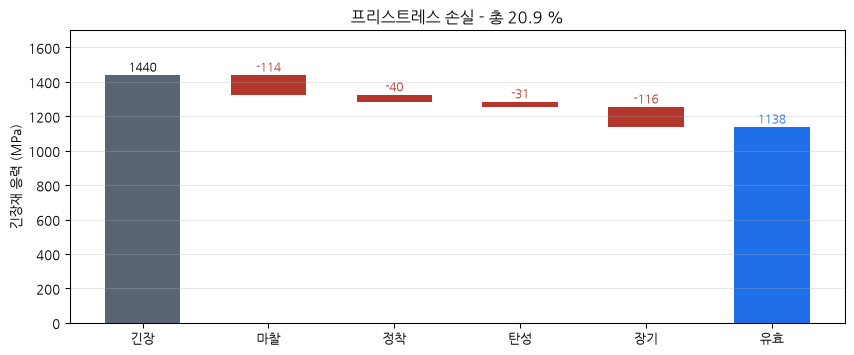

In [8]:
fig, ax = plt.subplots(figsize=(9, 3.8))

level = losses.f_jack
ax.bar(0, level, color="#5b6472", width=0.6)
ax.text(0, level + 25, f"{level:.0f}", ha="center", fontsize=9)
for i, d in enumerate([losses.friction, losses.anchorage,
                       losses.elastic, losses.long_term], start=1):
    ax.bar(i, d, bottom=level - d, color="#b3372c", width=0.6)
    ax.text(i, level + 25, f"-{d:.0f}", ha="center", fontsize=9,
            color="#b3372c")
    level -= d
ax.bar(5, level, color="#1f6feb", width=0.6)
ax.text(5, level + 25, f"{level:.0f}", ha="center", fontsize=9,
        color="#1f6feb")

ax.set_xticks(range(6))
ax.set_xticklabels(["긴장", "마찰", "정착", "탄성", "장기", "유효"])
ax.set_ylabel("긴장재 응력 (MPa)")
ax.set_title(f"프리스트레스 손실 - 총 {losses.total_ratio * 100:.1f} %")
ax.set_ylim(0, losses.f_jack * 1.18)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## ⑤ 사용한계상태 응력

긴장 직후에는 하연이 눌리고, 사용 시에는 하중이 그것을 되돌린다.

In [9]:
print(f"{'단계':14} {'상연':>9} {'하연':>9}   "
      f"{'압축 한계':>10} {'인장 한계':>10}")
for key in ("긴장 직후", "지속하중", "사용"):
    top, bot = result.stresses[key]
    hi, lo = result.limits[key]
    print(f"{key:14} {top:9.2f} {bot:9.2f}   {hi:10.2f} {lo:10.2f}")
print()
f_ctk = characteristic_tensile_strength(fck=FCK)
print(f"사용 시 하연 인장 {-result.stresses['사용'][1]:.2f} MPa "
      f"<= f_ctk {f_ctk:.2f} MPa  ->  비균열")

단계                    상연        하연        압축 한계      인장 한계
긴장 직후               2.73      6.99        18.00       0.00
지속하중                7.36      1.48        18.00       0.00
사용                  8.94     -2.37        24.00      -2.62

사용 시 하연 인장 2.37 MPa <= f_ctk 2.62 MPa  ->  비균열


## ⑥ 극한한계상태 휨

In [10]:
shape = "바닥판을 넘어 T형" if result.flanged else "바닥판 안 (직사각형)"
print(f"압축부가 {shape},  중립축 c = {result.c_n:.0f} mm")
print(f"M_Rd = {result.m_rd:.0f} >= M_Ed = {result.m_ed:.0f} kN·m"
      f"   여유 {result.m_rd / result.m_ed:.2f} 배")

압축부가 바닥판 안 (직사각형),  중립축 c = 168 mm
M_Rd = 10091 >= M_Ed = 9945 kN·m   여유 1.01 배


## ⑦ 텐던 배치 — 왜 휘어 올리는가

지간 중앙에서는 편심이 클수록 좋다. 그런데 **단부에서는 자중 모멘트가
0** 이라 프리스트레스가 만드는 상연 인장을 상쇄할 것이 없다.

In [11]:
z_t = props.inertia / props.y_t
kern = z_t / props.area
f_ctk_t = characteristic_tensile_strength(fck=FCK_TRANSFER)
e_mid = props.y_b - TENDON_COVER
top_end = result.p_i / props.area - result.p_i * e_mid / z_t

print(f"핵거리  Z_t / A = {kern:.0f} mm")
print(f"중앙 편심        {e_mid:.0f} mm")
print()
print(f"중앙 편심을 단부까지 끌고 가면 상연 {top_end:.2f} MPa,")
print(f"즉 인장 {-top_end:.2f} MPa > 긴장 시 f_ctk {f_ctk_t:.2f} MPa")
print()
print(f"-> 단부에서 편심을 핵거리 {kern:.0f} mm 안으로 드레이프해야 한다.")

핵거리  Z_t / A = 457 mm
중앙 편심        762 mm

중앙 편심을 단부까지 끌고 가면 상연 -3.30 MPa,
즉 인장 3.30 MPa > 긴장 시 f_ctk 2.20 MPa

-> 단부에서 편심을 핵거리 457 mm 안으로 드레이프해야 한다.


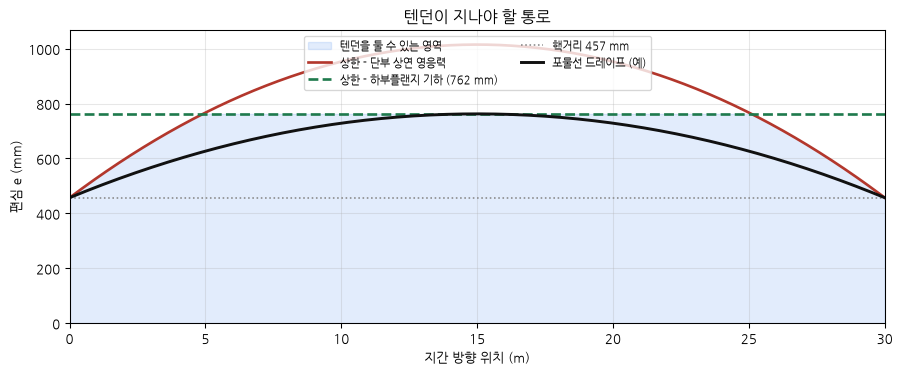

In [12]:
fig, ax = plt.subplots(figsize=(9.5, 4.0))

x = np.linspace(0, SPAN, 200)
w_self = GAMMA_CONCRETE * props.area / 1e6
m_self = w_self * x * (SPAN - x) / 2.0
p = result.p_i

e_zero = z_t / props.area + m_self * 1e6 / p     # 영응력 상한
ax.fill_between(x, 0, np.minimum(e_zero, e_mid), color="#1f6feb",
                alpha=0.13, label="텐던을 둘 수 있는 영역")
ax.plot(x, e_zero, color="#b3372c", lw=2, label="상한 - 단부 상연 영응력")
ax.axhline(e_mid, color="#1f7a4d", lw=2, ls="--",
           label=f"상한 - 하부플랜지 기하 ({e_mid:.0f} mm)")
ax.axhline(kern, color="#888", lw=1.2, ls=":",
           label=f"핵거리 {kern:.0f} mm")

e_drape = kern + (e_mid - kern) * (1 - (1 - 2 * x / SPAN) ** 2)
ax.plot(x, e_drape, color="#111", lw=2.2, label="포물선 드레이프 (예)")

ax.set_xlabel("지간 방향 위치 (m)")
ax.set_ylabel("편심 e (mm)")
ax.set_title("텐던이 지나야 할 통로")
ax.set_xlim(0, SPAN)
ax.set_ylim(0, e_mid * 1.4)
ax.legend(fontsize=8.5, ncol=2, loc="upper center")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## ⑧ 지간별 최소 강연선 수량

지간마다 가닥 수를 1 개씩 늘려 모든 한계상태를 만족하는 최소값을 찾고,
한 가닥 모자랄 때 무엇이 깨지는지 기록한다.

In [13]:
CASES = [("PSC-I 1.4m", 20.0), ("PSC-I 1.7m", 25.0),
         ("PSC-I 2.0m", 30.0), ("PSC-I 2.0m", 35.0),
         ("PSC-I 2.3m", 40.0), ("PSC-I 2.7m", 45.0),
         ("PSC-I 2.7m", 50.0)]

table = []
for name, span in CASES:
    section = EXAMPLE_SECTIONS[name]
    for n in range(6, 141):
        trial = design_girder(section=section, span=span,
                              a_p=n * STRAND_AREA)
        if trial.adequate:
            break
    short = design_girder(section=section, span=span,
                          a_p=(n - 1) * STRAND_AREA)
    gov = ", ".join(k for k, v in short.checks.items() if not v)
    table.append((name, span, n, trial, gov))

print(f"{'단면':12} {'지간':>5} {'가닥':>5} {'손실':>7} "
      f"{'M_Rd/M_Ed':>10}  한 가닥 모자랄 때")
for name, span, n, trial, gov in table:
    print(f"{name:12} {span:5.0f} {n:5d} "
          f"{trial.losses.total_ratio * 100:6.1f} % "
          f"{trial.m_rd / trial.m_ed:10.2f}  {gov}")

단면              지간    가닥      손실  M_Rd/M_Ed  한 가닥 모자랄 때
PSC-I 1.4m      20    16   20.5 %       1.05  설계휨강도
PSC-I 1.7m      25    20   20.5 %       1.01  사용 비균열, 설계휨강도
PSC-I 2.0m      30    25   20.9 %       1.01  사용 비균열, 설계휨강도
PSC-I 2.0m      35    36   23.1 %       1.09  사용 비균열
PSC-I 2.3m      40    42   23.3 %       1.09  사용 비균열
PSC-I 2.7m      45    48   23.7 %       1.11  사용 비균열
PSC-I 2.7m      50    61   25.5 %       1.14  사용 비균열


**짧은 지간은 극한 휨강도가, 35 m 이상은 사용한계상태 균열이 수량을
정한다.** 극한 여유가 1.09 ~ 1.14 배로 남는데도 강연선을 더 넣어야
한다. 한계상태설계법이라고 해서 극한이 항상 지배하는 것이 아니다.

## ⑨ KDS 14 강도설계법과의 대조

In [14]:
d_p = SECTION.height + HAUNCH + DECK_THICKNESS - TENDON_COVER
b_eff = GIRDER_SPACING * 1000.0

alpha_eq, beta_eq = equivalent_block(fck=FCK_DECK)
lam = 2.0 * beta_eq
eta24 = alpha_eq / lam
f_cd = design_compressive_strength(fck=FCK_DECK)
f_pd = design_yield_strength(fy=FPY)
t24 = a_p * f_pd
a24 = t24 / (eta24 * f_cd * b_eff)
m_rd24 = t24 * (d_p - a24 / 2.0) / 1e6

_, eta14, _ = stress_block_parameters(fck=FCK_DECK)
t14 = a_p * FPY
a14 = t14 / (eta14 * 0.85 * FCK_DECK * b_eff)
m_n = t14 * (d_p - a14 / 2.0) / 1e6

print(f"유효깊이 d_p = {d_p:.0f} mm,  b_eff = {b_eff:.0f} mm")
print()
print(f"{'':8} {'강재':>9} {'콘크리트':>10} {'a (mm)':>9} {'강도':>12}")
print(f"{'KDS 24':8} {f_pd:9.0f} {f_cd:10.2f} {a24:9.0f} {m_rd24:12.0f}")
print(f"{'KDS 14':8} {FPY:9.0f} {eta14 * 0.85 * FCK_DECK:10.2f} "
      f"{a14:9.0f} {m_n:12.0f}")
print(f"{'':8} {'':9} {'':10} {'x 0.85':>9} {0.85 * m_n:12.0f}")
print()
gap = m_rd24 / (0.85 * m_n)
print(f"KDS 24 / KDS 14 = {gap:.3f}  ({(gap - 1) * 100:+.1f} %)")

유효깊이 d_p = 2090 mm,  b_eff = 2500 mm

                강재       콘크리트    a (mm)           강도
KDS 24        1440      14.92       138        10091
KDS 14        1600      22.95        97        11327
                                 x 0.85         9628

KDS 24 / KDS 14 = 1.048  (+4.8 %)


휨은 **강재의 인장력이 지배**하므로 KDS 24 의 $\phi_s = 0.90$ 이
KDS 14 의 단면 $\phi = 0.85$ 보다 덜 깎는다. 콘크리트에 걸린 0.65 는
압축블록을 깊게 할 뿐(97 → 138 mm) 팔길이를 조금 줄이는 데 그친다.

L2 에서 본 철근콘크리트 보의 $+3.9\,\%$ 와 같은 방향, 비슷한 크기다.

:::{note}
두 기준의 **안전율 배치**만 견주려고 강재 응력을 양쪽 모두 $f_{py}$ 로
두었다. 실제 KDS 14 설계에서는 부착 긴장재의 극한 응력 $f_{ps}$ 를
따로 산정한다.
:::

## 설계 요약

In [15]:
print(f"거더        {SECTION.name}, 지간 {SPAN:.0f} m, "
      f"간격 {GIRDER_SPACING:.1f} m")
print(f"콘크리트     거더 {FCK:.0f} / 긴장 시 {FCK_TRANSFER:.0f} / "
      f"바닥판 {FCK_DECK:.0f} MPa")
print(f"긴장재       15.2 mm x {N_STRAND} 가닥 (A_p {a_p:.0f} mm²), "
      f"e = {props.y_b - TENDON_COVER:.0f} mm")
print(f"프리스트레스  P_i {result.p_i / 1e3:.0f} -> "
      f"P_e {result.p_e / 1e3:.0f} kN "
      f"(손실 {losses.total_ratio * 100:.1f} %)")
print()
for name, ok in result.checks.items():
    print(f"  {'만족  ' if ok else '불만족'}  {name}")
print(f"\n종합 판정: {'만족' if result.adequate else '불만족'}")

거더        PSC-I 2.0m, 지간 30 m, 간격 2.5 m
콘크리트     거더 40 / 긴장 시 30 / 바닥판 27 MPa
긴장재       15.2 mm x 25 가닥 (A_p 3467 mm²), e = 762 mm
프리스트레스  P_i 4351 -> P_e 3948 kN (손실 20.9 %)

  만족    긴장 직후 압축
  만족    긴장 직후 인장
  만족    지속하중 압축
  만족    지속하중 영응력
  만족    사용 압축
  만족    사용 비균열
  만족    바닥판 압축
  만족    도입 직후 응력
  만족    긴장재 응력
  만족    설계휨강도
  만족    형고/지간

종합 판정: 만족


## 정리

1. **넣은 프리스트레스의 21 % 가 사라진다.** 가장 큰 몫은 마찰(7.9 %)
   이고, 이것이 설계자가 배치로 줄일 수 있는 유일한 큰 손실이다.
2. **하중의 59 % 는 합성 단면의 혜택을 못 받는다.** 거더 자중과 바닥판이
   합성 전에 실리기 때문이다.
3. **단부와 중앙의 허용 편심이 다르다.** 중앙 762 mm, 단부 457 mm —
   이 차이가 텐던을 휘게 만든다.
4. **35 m 를 넘으면 사용한계상태가 단면을 정한다.** 극한 휨강도가
   남는데도 그렇다.
5. **식 $(1.5\text{-}9)$ 는 읽기가 갈린다.** 원문대로면 이 거더가
   걸리고, EN 해석이면 통과한다. 설계 전에 정해 두어야 할 사항이다.